In [ ]:
# plot the image with cooridates and centre an aperture based on SNR coordinates with width given in paper

AttributeError: 'SkyCircularAperture' object has no attribute 'plot'

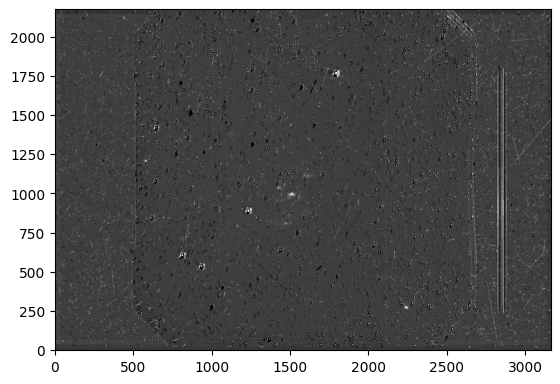

In [1]:
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt

from astropy.coordinates import SkyCoord
from astropy import units as u
from photutils.aperture import SkyCircularAperture, aperture_photometry


data = np.asarray(fits.open("test_sub.fits")[0].data, dtype=np.float32)
plt.imshow(data, cmap='gray', origin='lower', vmin=np.percentile(data,1), vmax=np.percentile(data,99.5))


coord = SkyCoord("05h47m50s", "-70d24m45s", frame="icrs")
aperture = SkyCircularAperture(coord, r=54*u.arcsec)

aperture.plot()

plt.show()

Extensions in WCS file:
Filename: images/SNR_OIII.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     214   ()      
  1  SCI           1 ImageHDU       148   (3164, 2175)   float32   
  2  VAR           1 ImageHDU       148   (3164, 2175)   float32   
  3  DQ            1 ImageHDU       148   (3164, 2175)   int16 (rescales to uint16)   
  4  OBJMASK       1 ImageHDU       148   (3164, 2175)   uint8   
  5  OBJCAT        1 BinTableHDU    169   8943R x 43C   [K, D, D, D, D, D, D, D, D, D, D, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, J, I, J, J, E, J, E, E, E, E]   
  6  HISTORY       1 BinTableHDU     17   18R x 4C   [128A, 288A, 28A, 28A]   
  7  PROVENANCE    1 BinTableHDU     17   9R x 4C   [28A, 128A, 128A, 128A]   
Using WCS from SCI extension


Mean: 0.0025585521447491514
Median: 0.002906264566849838
Std: 0.0022407845029507323
Aperture center: [1509.5777885  1102.69167886]
Radius: 337.14610920598693


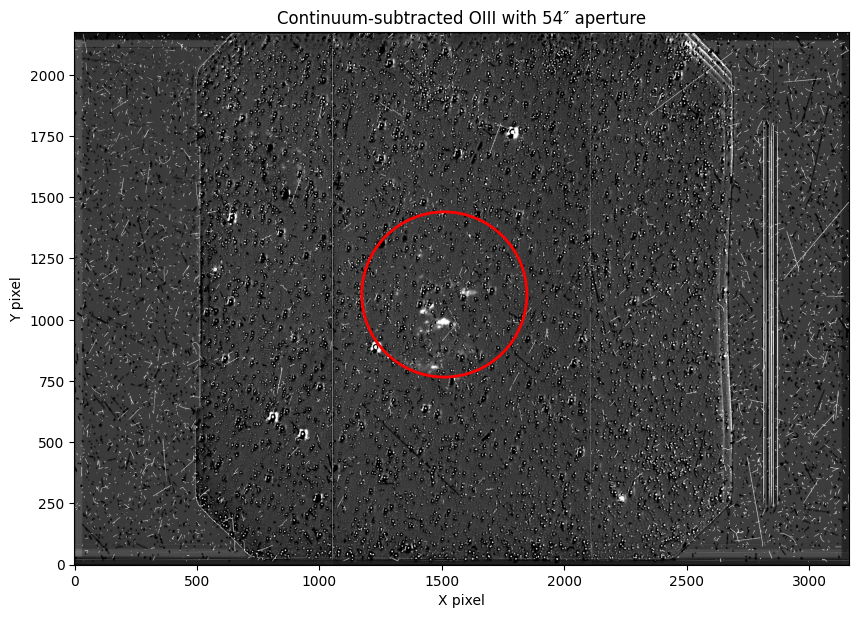

In [16]:
import matplotlib.pyplot as plt

from astropy.io import fits
from astropy.wcs import WCS
from astropy.stats import sigma_clipped_stats
from astropy.coordinates import SkyCoord
from astropy import units as u

from photutils.aperture import SkyCircularAperture

# -----------------------------
# File names
# -----------------------------
sub_file = "test_sub.fits"      # your continuum-subtracted image
wcs_file = "images/SNR_OIII.fits"      # original DRAGONS OIII reduction

# -----------------------------
# Load subtraction image data
# -----------------------------
sub_hdul = fits.open(sub_file)
data = sub_hdul[0].data

# -----------------------------
# Load WCS from original DRAGONS file
# -----------------------------
oiii_hdul = fits.open(wcs_file)

print("Extensions in WCS file:")
oiii_hdul.info()

# Try common DRAGONS science extension first
try:
    wcs = WCS(oiii_hdul["SCI"].header)
    print("Using WCS from SCI extension")
except KeyError:
    wcs = WCS(oiii_hdul[1].header)
    print("Using WCS from extension 1")

# -----------------------------
# Background statistics
# -----------------------------
mean, median, std = sigma_clipped_stats(data, sigma=3.0, maxiters=5)

print("Mean:", mean)
print("Median:", median)
print("Std:", std)

# -----------------------------
# Define 54 arcsec sky aperture
# -----------------------------
coord = SkyCoord("05h47m50s", "-70d24m45s", frame="icrs")

sky_ap = SkyCircularAperture(
    coord,
    r=54 * u.arcsec
)

pix_ap = sky_ap.to_pixel(wcs)

print("Aperture center:", pix_ap.positions)
print("Radius:", pix_ap.r)

# -----------------------------
# Plot image with aperture
# -----------------------------
fig, ax = plt.subplots(figsize=(10, 8))

ax.imshow(
    data,
    origin="lower",
    cmap="gray",
    vmin=median - 3 * std,
    vmax=median + 10 * std
)

pix_ap.plot(
    ax=ax,
    color="red",
    lw=2
)

ax.set_title("Continuum-subtracted OIII with 54″ aperture")
ax.set_xlabel("X pixel")
ax.set_ylabel("Y pixel")

plt.show()

In [17]:
from photutils.aperture import aperture_photometry

phot = aperture_photometry(data, pix_ap)

ap_sum = phot["aperture_sum"][0]
ap_area = pix_ap.area

ap_mean = ap_sum / ap_area
net_mean = ap_mean - median

print("Aperture sum:", ap_sum)
print("Aperture area:", ap_area)
print("Mean inside aperture:", ap_mean)
print("Net mean above background:", net_mean)
print("Net mean / RMS:", net_mean / std)

Aperture sum: 1271.473342324667
Aperture area: 357096.9796618386
Mean inside aperture: 0.003560582740096874
Net mean above background: 0.0006543181732470362
Net mean / RMS: 0.2920040603571697


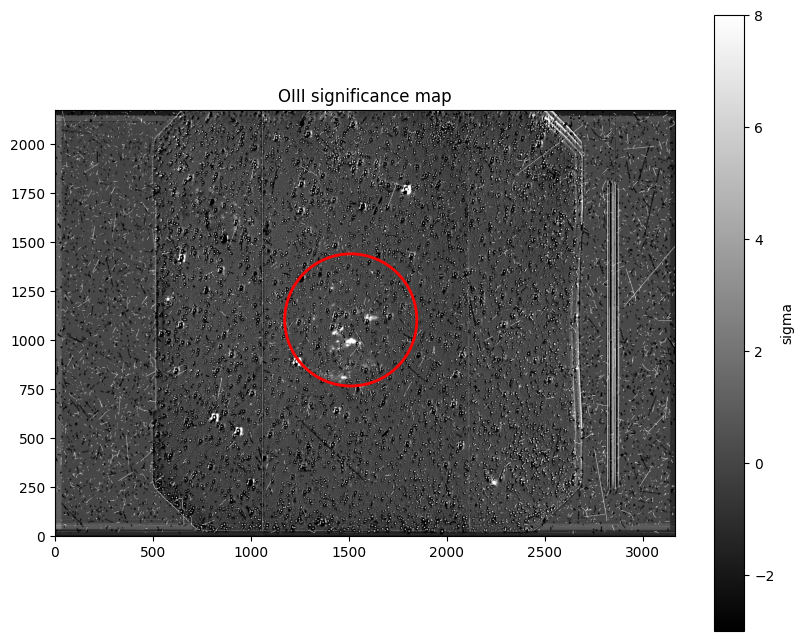

In [18]:
snr_map = (data - median) / std

plt.figure(figsize=(10, 8))
plt.imshow(snr_map, origin="lower", cmap="gray", vmin=-3, vmax=8)
pix_ap.plot(color="red", lw=2)
plt.colorbar(label="sigma")
plt.title("OIII significance map")
plt.show()

Using WCS from SCI extension
Global mean: 0.0025585521447491514
Global median: 0.002906264566849838
Global RMS/std: 0.0022407845029507323

Aperture results:
Label      Mean value      Net above median      Net/RMS
SNR        0.00356058     0.00065432           0.292
Right      0.00296800     0.00006174           0.028
Left       0.00534208     0.00243581           1.087
Up         0.00570550     0.00279924           1.249
Down       0.00282614    -0.00008012          -0.036


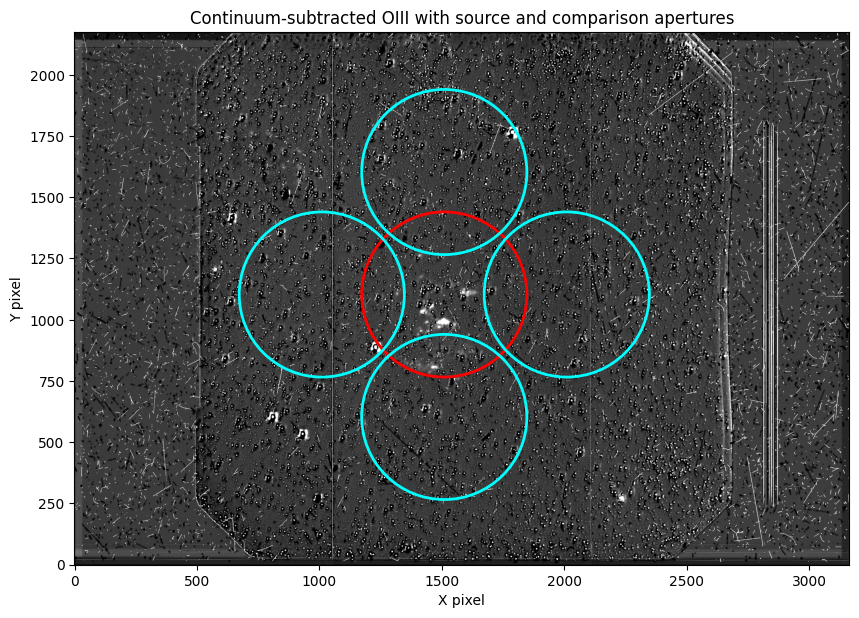

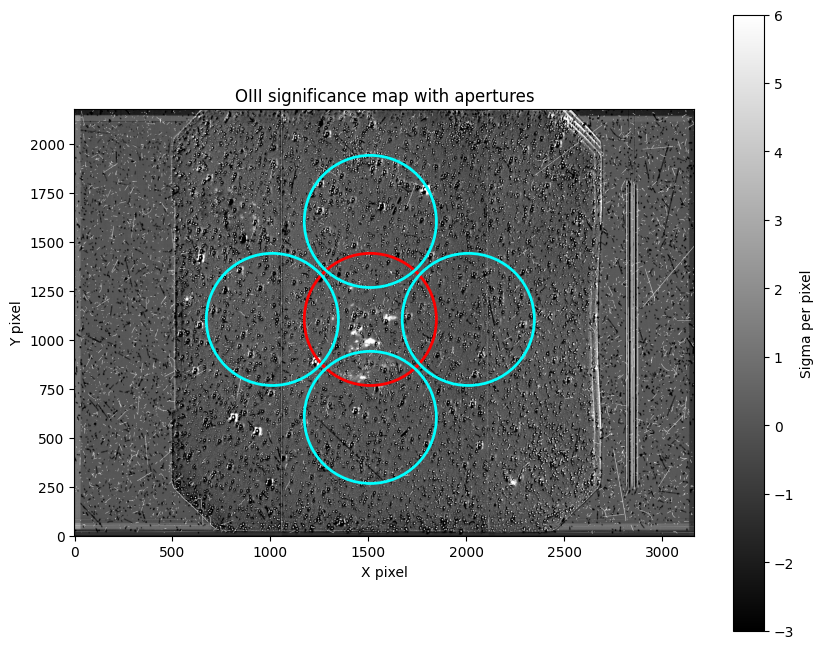

In [20]:
import matplotlib.pyplot as plt

from astropy.io import fits
from astropy.wcs import WCS
from astropy.stats import sigma_clipped_stats
from astropy.coordinates import SkyCoord
from astropy import units as u

from photutils.aperture import (
    SkyCircularAperture,
    CircularAperture,
    aperture_photometry
)

# -----------------------------
# Files
# -----------------------------
sub_file = "test_sub.fits"      # your subtracted image
wcs_file = "images/SNR_OIII.fits"      # original DRAGONS OIII output with WCS

# -----------------------------
# Load data and WCS
# -----------------------------
data = fits.getdata(sub_file)

oiii_hdul = fits.open(wcs_file)

try:
    wcs = WCS(oiii_hdul["SCI"].header)
    print("Using WCS from SCI extension")
except KeyError:
    wcs = WCS(oiii_hdul[1].header)
    print("Using WCS from extension 1")

# -----------------------------
# Background stats
# -----------------------------
mean, median, std = sigma_clipped_stats(data, sigma=3.0, maxiters=5)

print("Global mean:", mean)
print("Global median:", median)
print("Global RMS/std:", std)

# -----------------------------
# Source aperture: SNR 0548-70.4
# -----------------------------
coord = SkyCoord("05h47m50s", "-70d24m45s", frame="icrs")
sky_ap = SkyCircularAperture(coord, r=54*u.arcsec)
pix_ap = sky_ap.to_pixel(wcs)

x0, y0 = pix_ap.positions
r = pix_ap.r

source_ap = CircularAperture((x0, y0), r=r)

# -----------------------------
# Comparison apertures
# Adjust shifts if any aperture lands off image or on bright stars
# -----------------------------
shift = 500

comparison_aps = [
    CircularAperture((x0 + shift, y0), r=r),
    CircularAperture((x0 - shift, y0), r=r),
    CircularAperture((x0, y0 + shift), r=r),
    CircularAperture((x0, y0 - shift), r=r),
]

all_aps = [source_ap] + comparison_aps
labels = ["SNR", "Right", "Left", "Up", "Down"]

# -----------------------------
# Photometry
# -----------------------------
print("\nAperture results:")
print("Label      Mean value      Net above median      Net/RMS")

for label, ap in zip(labels, all_aps):
    phot = aperture_photometry(data, ap)
    ap_sum = phot["aperture_sum"][0]
    ap_mean = ap_sum / ap.area
    net = ap_mean - median
    net_sigma = net / std

    print(f"{label:8s}  {ap_mean: .8f}    {net: .8f}          {net_sigma: .3f}")

# -----------------------------
# Plot data with all apertures
# -----------------------------
fig, ax = plt.subplots(figsize=(10, 8))

ax.imshow(
    data,
    origin="lower",
    cmap="gray",
    vmin=median - 3*std,
    vmax=median + 10*std
)

source_ap.plot(ax=ax, color="red", lw=2, label="SNR aperture")

for ap in comparison_aps:
    ap.plot(ax=ax, color="cyan", lw=2)

ax.set_title("Continuum-subtracted OIII with source and comparison apertures")
ax.set_xlabel("X pixel")
ax.set_ylabel("Y pixel")

plt.show()

# -----------------------------
# Plot sigma/significance map
# -----------------------------
snr_map = (data - median) / std

fig, ax = plt.subplots(figsize=(10, 8))

ax.imshow(
    snr_map,
    origin="lower",
    cmap="gray",
    vmin=-3,
    vmax=6
)

source_ap.plot(ax=ax, color="red", lw=2)

for ap in comparison_aps:
    ap.plot(ax=ax, color="cyan", lw=2)

plt.colorbar(ax.images[0], ax=ax, label="Sigma per pixel")
ax.set_title("OIII significance map with apertures")
ax.set_xlabel("X pixel")
ax.set_ylabel("Y pixel")

plt.show()